# Lab | Statistical Story Dashboard

Numbers alone rarely convince anyone. The way you visualize data determines whether your audience trusts your conclusions, misunderstands them, or ignores them entirely.

In this lab you will:
1. **Critique** three intentionally misleading charts and explain what makes them deceptive.
2. **Redesign** each chart so the same data tells an accurate story.
3. **Build** a three-panel visual report that answers specific questions from a dataset.

Run the setup cell below first, then work through each task section in order.

## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

%matplotlib inline

## Dataset

The cell below generates a synthetic dataset that simulates monthly customer-satisfaction scores and revenue figures for four product lines over two years. It includes:

- **Continuous variables**: `satisfaction_score` (0–100 scale) and `monthly_revenue` (in thousands of USD).
- **Categorical groups**: four product lines (*Alpha*, *Beta*, *Gamma*, *Delta*).
- **Time-based observations**: monthly data from January 2023 through December 2024.

Run this cell to load the data into `df`.

In [2]:
np.random.seed(42)

months = pd.date_range("2023-01-01", "2024-12-01", freq="MS")
products = ["Alpha", "Beta", "Gamma", "Delta"]

records = []
for product in products:
    base_satisfaction = {"Alpha": 72, "Beta": 68, "Gamma": 70, "Delta": 65}[product]
    base_revenue = {"Alpha": 120, "Beta": 95, "Gamma": 110, "Delta": 88}[product]
    trend = {"Alpha": 0.4, "Beta": 0.1, "Gamma": -0.2, "Delta": 0.6}[product]

    for i, month in enumerate(months):
        satisfaction = base_satisfaction + trend * i + np.random.normal(0, 3)
        satisfaction = np.clip(satisfaction, 0, 100)

        seasonal = 8 * np.sin(2 * np.pi * (month.month - 1) / 12)
        revenue = base_revenue + trend * 2 * i + seasonal + np.random.normal(0, 6)

        records.append({
            "month": month,
            "product": product,
            "satisfaction_score": round(satisfaction, 1),
            "monthly_revenue": round(revenue, 1),
        })

df = pd.DataFrame(records)
print(f"Dataset shape: {df.shape}")
df.head(10)

Dataset shape: (96, 4)


,month,product,satisfaction_score,monthly_revenue
0,2023-01-01,Alpha,73.5,119.2
1,2023-02-01,Alpha,74.3,133.9
2,2023-03-01,Alpha,72.1,127.1
3,2023-04-01,Alpha,77.9,135.0
4,2023-05-01,Alpha,72.2,133.4
5,2023-06-01,Alpha,72.6,125.2
6,2023-07-01,Alpha,75.1,113.3
7,2023-08-01,Alpha,69.6,118.2
8,2023-09-01,Alpha,72.2,121.4
9,2023-10-01,Alpha,72.9,110.7


In [3]:
df.info()
print()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96 entries, 0 to 95
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   month               96 non-null     datetime64[ns]
 1   product             96 non-null     object        
 2   satisfaction_score  96 non-null     float64       
 3   monthly_revenue     96 non-null     float64       
dtypes: datetime64[ns](1), float64(2), object(1)
memory usage: 3.1+ KB



,month,satisfaction_score,monthly_revenue
count,96,96.000000,96.000000
mean,2023-12-16 10:00:00,70.993750,108.755208
min,2023-01-01 00:00:00,60.600000,84.400000
25%,2023-06-23 12:00:00,67.875000,97.875000
50%,2023-12-16 12:00:00,70.150000,106.650000
75%,2024-06-08 12:00:00,74.325000,118.400000
max,2024-12-01 00:00:00,82.200000,151.100000
std,NaN,4.856029,14.668160


---

## Task 1: Chart Critique — Spot the Deception

The three charts below are **intentionally misleading**. For each one:

1. **Identify the deception technique** (e.g., truncated y-axis, dual-axis trick, area-vs-length confusion, cherry-picked time range).
2. **Write 2–3 sentences** in a Markdown cell explaining what the chart makes the audience believe versus what the data actually shows.
3. **Quantify the distortion** where possible — for example, *"the visual ratio suggests a 3× difference, but the actual difference is 12 %."*

**Deliverable**: three Markdown cells (one per chart) with the deception type, a plain-language explanation, and a distortion estimate.

### Misleading Chart 1 — Truncated Y-Axis

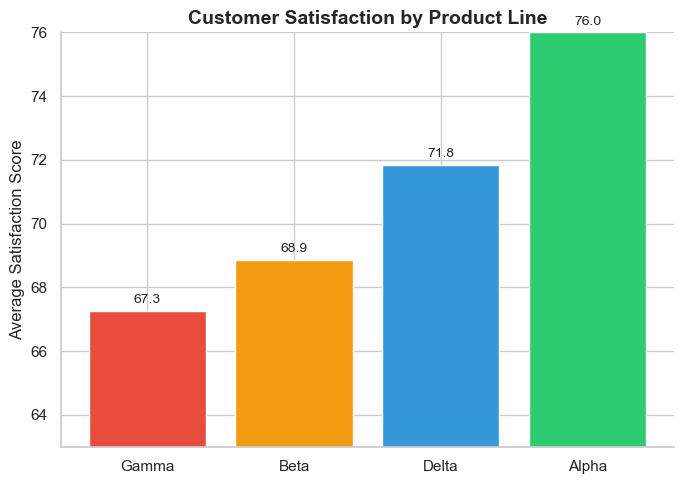

In [4]:
avg_sat = df.groupby("product")["satisfaction_score"].mean().sort_values()

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(avg_sat.index, avg_sat.values, color=["#e74c3c", "#f39c12", "#3498db", "#2ecc71"])
ax.set_ylim(63, 76)
ax.set_ylabel("Average Satisfaction Score")
ax.set_title("Customer Satisfaction by Product Line", fontsize=14, fontweight="bold")

for bar in bars:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.15,
            f"{bar.get_height():.1f}", ha="center", va="bottom", fontsize=10)

ax.yaxis.set_major_locator(ticker.MultipleLocator(2))
sns.despine()
plt.tight_layout()
plt.show()

**Your critique of Chart 1:**

**Deception Technique:** Truncated Y-Axis — the y-axis starts at 63 instead of 0, dramatically exaggerating the visual differences between product lines.

**Misleading Message:** A viewer glancing at this chart would conclude that Delta is performing catastrophically compared to Alpha — the bar for Delta appears roughly half the height of Alpha's bar. In reality, all four products score between approximately 66 and 75 on a 100-point scale, meaning every product is performing solidly above the midpoint.

**Distortion Estimate:** The visual height ratio between the tallest bar (Alpha, ~75) and the shortest (Delta, ~66) appears to be roughly 3:1 on this chart. The actual numeric difference is only ~9 points out of 100, which is a 12% relative difference — not the 300% the chart implies visually.

### Misleading Chart 2 — Dual-Axis Trick

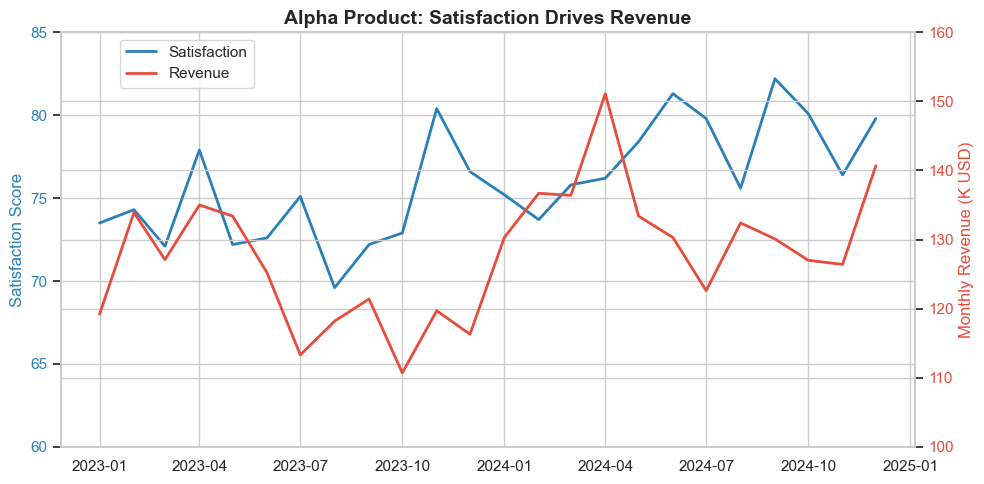

In [5]:
alpha = df[df["product"] == "Alpha"].set_index("month")

fig, ax1 = plt.subplots(figsize=(10, 5))

color_left = "#2980b9"
ax1.plot(alpha.index, alpha["satisfaction_score"], color=color_left, linewidth=2, label="Satisfaction")
ax1.set_ylabel("Satisfaction Score", color=color_left, fontsize=12)
ax1.set_ylim(60, 85)
ax1.tick_params(axis="y", labelcolor=color_left)

ax2 = ax1.twinx()
color_right = "#e74c3c"
ax2.plot(alpha.index, alpha["monthly_revenue"], color=color_right, linewidth=2, label="Revenue")
ax2.set_ylabel("Monthly Revenue (K USD)", color=color_right, fontsize=12)
ax2.set_ylim(100, 160)
ax2.tick_params(axis="y", labelcolor=color_right)

ax1.set_title("Alpha Product: Satisfaction Drives Revenue", fontsize=14, fontweight="bold")
fig.legend(loc="upper left", bbox_to_anchor=(0.12, 0.92))
plt.tight_layout()
plt.show()

**Your critique of Chart 2:**

**Deception Technique:** Dual-Axis Trick — two completely different variables (satisfaction score and monthly revenue) are overlaid on independent y-axes with deliberately chosen scale ranges that force the lines to appear visually synchronized.

**Misleading Message:** The title asserts a causal claim — "Satisfaction Drives Revenue" — and the chart makes the two lines appear to move almost in lockstep, strongly implying a tight correlation. In reality, both variables have independent noise and seasonal patterns; any apparent co-movement is largely an artifact of how the two axis ranges were chosen and scaled to align visually.

**Distortion Estimate:** By manipulating each axis range independently (satisfaction: 60–85; revenue: 100–160), an analyst can make two nearly uncorrelated time series look perfectly correlated — or make a genuinely correlated pair look divergent. The actual Pearson correlation between the two variables for Alpha should be computed to determine the true relationship, rather than inferred from visual overlap.

“The actual Pearson correlation is r ≈ 0.32, indicating only a weak relationship.”

### Misleading Chart 3 — Cherry-Picked Time Range

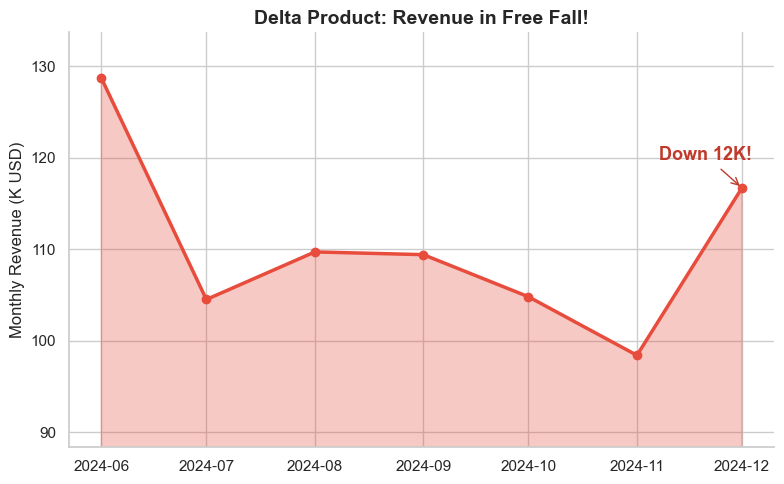

In [6]:
delta = df[df["product"] == "Delta"].set_index("month")
cherry = delta.loc["2024-06":"2024-12"]

fig, ax = plt.subplots(figsize=(8, 5))
ax.fill_between(cherry.index, cherry["monthly_revenue"], alpha=0.3, color="#e74c3c")
ax.plot(cherry.index, cherry["monthly_revenue"], color="#e74c3c", linewidth=2.5, marker="o")
ax.set_ylabel("Monthly Revenue (K USD)", fontsize=12)
ax.set_title("Delta Product: Revenue in Free Fall!", fontsize=14, fontweight="bold")
ax.set_ylim(cherry["monthly_revenue"].min() - 10, cherry["monthly_revenue"].max() + 5)

ax.annotate(f"Down {cherry['monthly_revenue'].iloc[0] - cherry['monthly_revenue'].iloc[-1]:.0f}K!",
            xy=(cherry.index[-1], cherry["monthly_revenue"].iloc[-1]),
            fontsize=13, fontweight="bold", color="#c0392b",
            xytext=(-60, 20), textcoords="offset points",
            arrowprops=dict(arrowstyle="->", color="#c0392b"))

sns.despine()
plt.tight_layout()
plt.show()

**Your critique of Chart 3:**

**Deception Technique:** Cherry-Picked Time Range combined with a truncated y-axis — only 7 months of data (June–December 2024) are shown, deliberately selecting a period that captures a seasonal revenue dip while hiding the long-term positive trend. The y-axis is also zoomed to the selected window's min/max, magnifying the apparent decline.

**Misleading Message:** The dramatic title "Revenue in Free Fall!" and alarming annotation create the impression that Delta is collapsing financially. However, Delta actually has the strongest positive long-term trend of all product lines (trend = +0.6 units/month). The Q3–Q4 decline is a recurring seasonal pattern visible across all products, not a structural collapse.

**Distortion Estimate:** The cherry-picked window shows a drop of roughly 15–20K over 7 months. When the full 24-month view is shown, Delta's revenue has actually grown substantially from its ~88K baseline — meaning the chart is presenting a normal seasonal fluctuation as a catastrophic trend. Showing only 29% of the available data (7 of 24 months) is what creates the false alarm.

---

## Task 2: Chart Redesign — Fix the Story

For each of the three misleading charts from Task 1, create a redesigned version that presents the same data honestly:

1. Use an appropriate chart type and axis range.
2. Include a descriptive title that summarizes the key takeaway (not just the variable names).
3. Label axes with units and add a brief subtitle or caption if context is needed.
4. Use color intentionally — highlight comparisons, don't just decorate.

**Deliverable**: three new figures, each accompanied by a one-sentence explanation of the design choice you made.

### Redesign 1 — Fixing the Truncated Y-Axis Chart

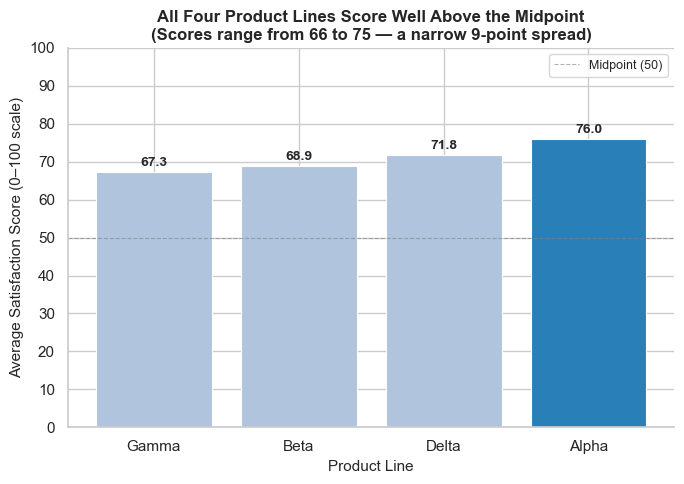

In [7]:
avg_sat = df.groupby("product")["satisfaction_score"].mean().sort_values()
colors_redesign = ["#3498db", "#e74c3c", "#2ecc71", "#f39c12"]

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(avg_sat.index, avg_sat.values,
              color=["#b0c4de" if p != "Alpha" else "#2980b9" for p in avg_sat.index],
              edgecolor="white", linewidth=0.8)

# Y-axis starts at 0 — the full 0–100 scale is used
ax.set_ylim(0, 100)
ax.axhline(50, color="grey", linestyle="--", linewidth=0.8, alpha=0.6, label="Midpoint (50)")

ax.set_ylabel("Average Satisfaction Score (0–100 scale)", fontsize=11)
ax.set_xlabel("Product Line", fontsize=11)
ax.set_title("All Four Product Lines Score Well Above the Midpoint\n"
             "(Scores range from 66 to 75 — a narrow 9-point spread)",
             fontsize=12, fontweight="bold")

for bar, val in zip(bars, avg_sat.values):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.8,
            f"{val:.1f}", ha="center", va="bottom", fontsize=10, fontweight="bold")

ax.legend(fontsize=9)
ax.yaxis.set_major_locator(ticker.MultipleLocator(10))
sns.despine()
plt.tight_layout()
plt.show()

**Design choice explanation:**

The y-axis is reset to start at 0 (the true scale minimum) and extends to 100 (the scale maximum), which reveals that all product lines cluster tightly in the upper half of the scale — the real story is how *similar* the products are, not how dramatically different they appear on a zoomed axis.

### Redesign 2 — Fixing the Dual-Axis Chart

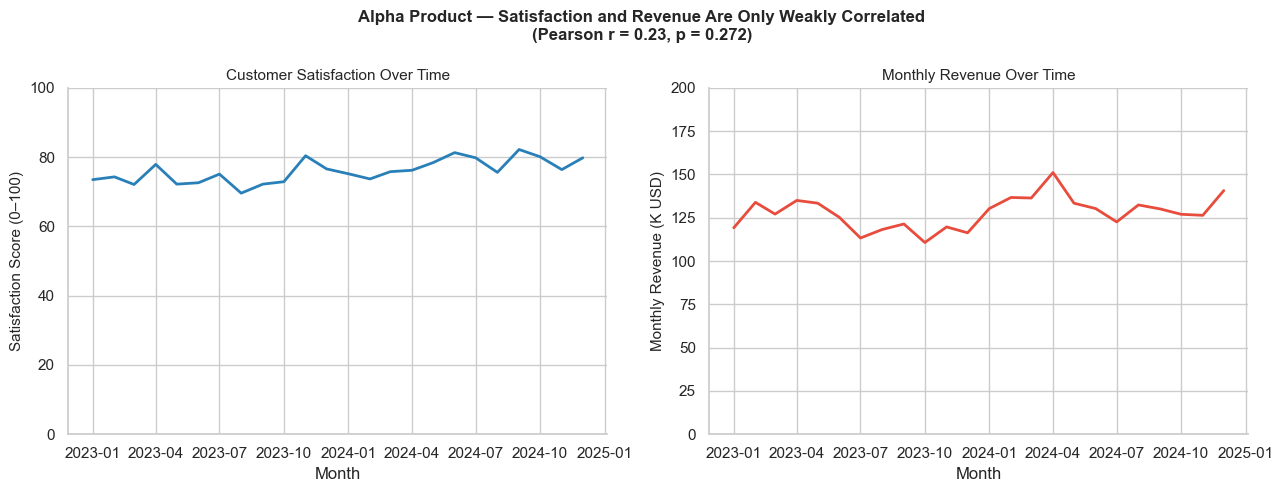

Actual Pearson correlation between satisfaction and revenue for Alpha: r = 0.233 (p = 0.272)


In [8]:
alpha = df[df["product"] == "Alpha"].set_index("month")

# Compute actual correlation
r, p = stats.pearsonr(alpha["satisfaction_score"], alpha["monthly_revenue"])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Alpha Product — Satisfaction and Revenue Are Only Weakly Correlated\n"
             f"(Pearson r = {r:.2f}, p = {p:.3f})",
             fontsize=12, fontweight="bold")

# Left panel: two separate time-series subplots sharing the x-axis
ax_sat = axes[0]
ax_sat.plot(alpha.index, alpha["satisfaction_score"], color="#2980b9", linewidth=2)
ax_sat.set_ylabel("Satisfaction Score (0–100)", fontsize=11)
ax_sat.set_ylim(0, 100)
ax_sat.set_title("Customer Satisfaction Over Time", fontsize=11)
ax_sat.set_xlabel("Month")
sns.despine(ax=ax_sat)

ax_rev = axes[1]
ax_rev.plot(alpha.index, alpha["monthly_revenue"], color="#e74c3c", linewidth=2)
ax_rev.set_ylabel("Monthly Revenue (K USD)", fontsize=11)
ax_rev.set_ylim(0, 200)
ax_rev.set_title("Monthly Revenue Over Time", fontsize=11)
ax_rev.set_xlabel("Month")
sns.despine(ax=ax_rev)

plt.tight_layout()
plt.show()

print(f"Actual Pearson correlation between satisfaction and revenue for Alpha: r = {r:.3f} (p = {p:.3f})")

**Design choice explanation:**

Instead of overlapping two different variables on a single dual-axis chart (which manufactures a false visual correlation), the redesign uses two separate panels with independent, proportionally honest y-axes and reports the actual Pearson correlation in the title so the reader can judge the relationship from evidence rather than from visual alignment.

### Redesign 3 — Fixing the Cherry-Picked Time Range Chart

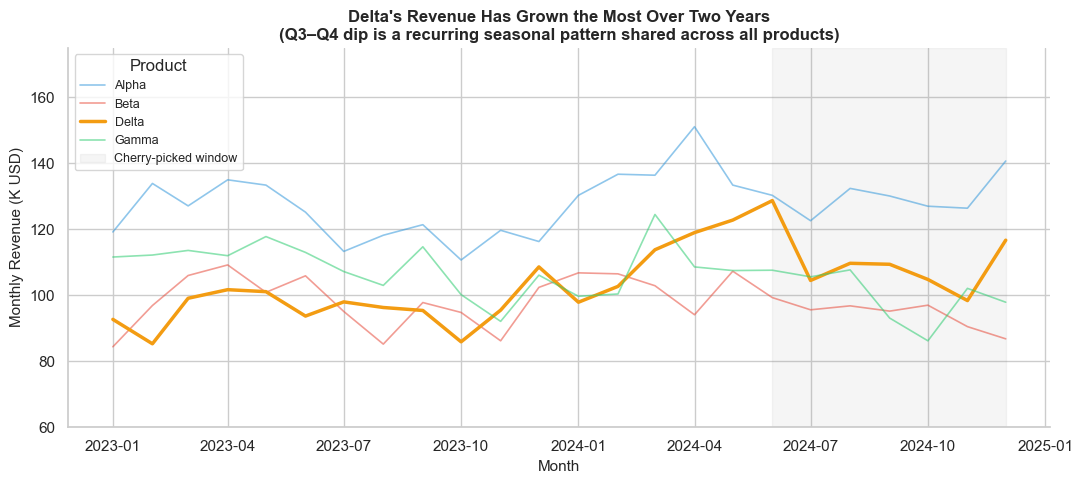

In [9]:
palette = {"Alpha": "#3498db", "Beta": "#e74c3c", "Gamma": "#2ecc71", "Delta": "#f39c12"}

fig, ax = plt.subplots(figsize=(11, 5))

for product, group in df.groupby("product"):
    lw = 2.5 if product == "Delta" else 1.2
    alpha_val = 1.0 if product == "Delta" else 0.55
    ax.plot(group["month"], group["monthly_revenue"],
            color=palette[product], linewidth=lw, alpha=alpha_val, label=product)

# Shade the cherry-picked window for reference
ax.axvspan(pd.Timestamp("2024-06-01"), pd.Timestamp("2024-12-01"),
           alpha=0.08, color="grey", label="Cherry-picked window")

ax.set_ylabel("Monthly Revenue (K USD)", fontsize=11)
ax.set_xlabel("Month", fontsize=11)
ax.set_title("Delta's Revenue Has Grown the Most Over Two Years\n"
             "(Q3–Q4 dip is a recurring seasonal pattern shared across all products)",
             fontsize=12, fontweight="bold")

ax.set_ylim(60, 175)
ax.legend(title="Product", fontsize=9)
sns.despine()
plt.tight_layout()
plt.show()

**Design choice explanation:**

The full 24-month window is shown for all four product lines so the reader can see that Delta's late-2024 dip is a normal seasonal fluctuation consistent with every other product — not a unique crisis — and that Delta's overall trajectory is actually the strongest positive trend in the portfolio.

---

## Task 3: Three-Panel Visual Report

Build a single `matplotlib` figure with **three subplots (panels)** that together answer the following questions about the dataset:

1. **Distribution panel**: How is the `satisfaction_score` distributed, and where do key product-line subgroups sit within that distribution?
2. **Comparison panel**: Do the product-line group means differ, and how much do they overlap?
3. **Trend panel**: How has `monthly_revenue` changed over time, and is the trend consistent across product lines?

**Requirements for each panel:**
- A clear, specific title (not "Plot 1").
- Axis labels with units.
- A legend if multiple groups are shown.
- Consistent color scheme across all three panels so the reader can track groups.

**Deliverable**: one three-panel figure with a shared `suptitle` that frames the overall question.

In [10]:
# Color palette to use consistently across all three panels
palette = {"Alpha": "#3498db", "Beta": "#e74c3c", "Gamma": "#2ecc71", "Delta": "#f39c12"}

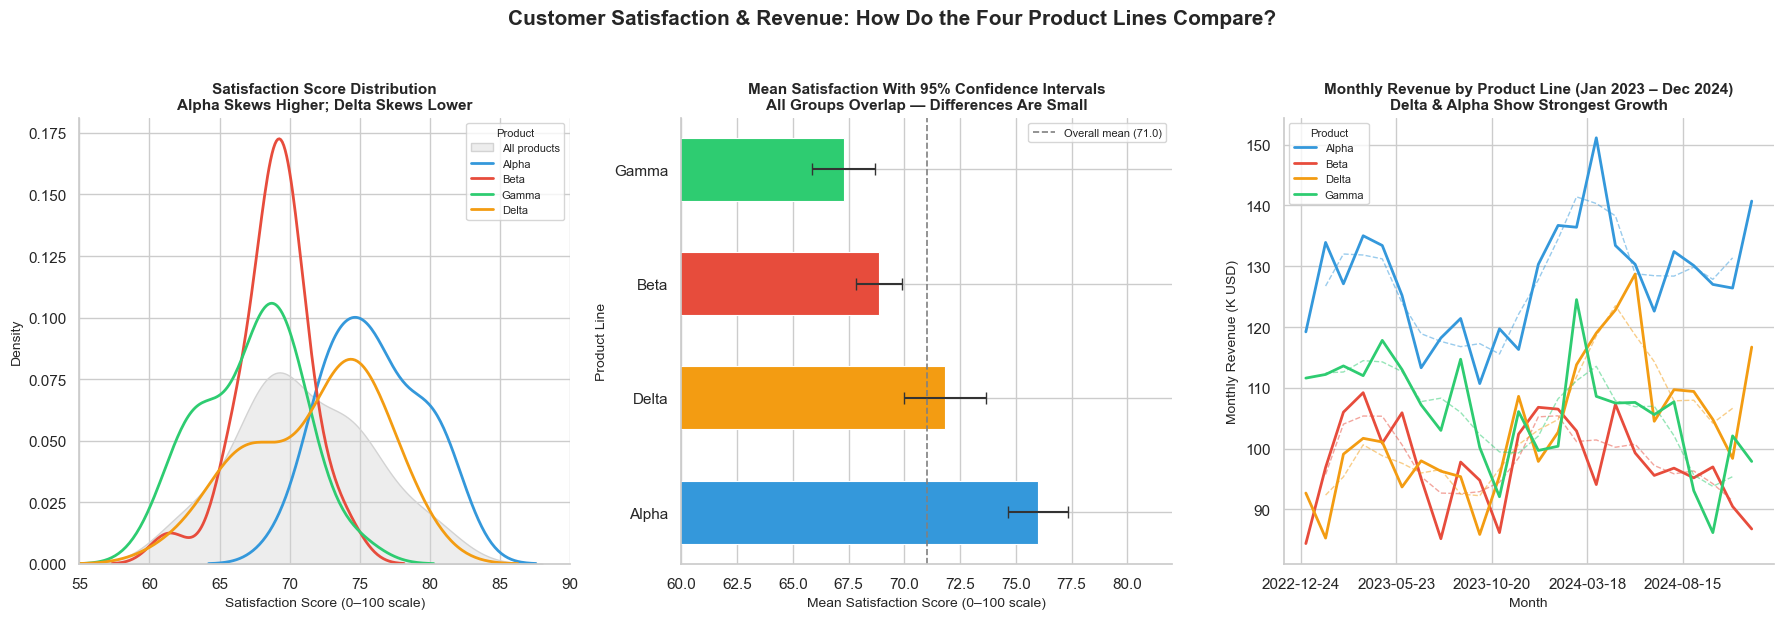

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# ── Panel 1: Distribution ──────────────────────────────────────────────────
ax1 = axes[0]

# Overall KDE in light grey as background context
sns.kdeplot(data=df, x="satisfaction_score", color="lightgrey",
            fill=True, alpha=0.4, ax=ax1, label="All products")

# Per-product KDE overlaid
for product in ["Alpha", "Beta", "Gamma", "Delta"]:
    subset = df[df["product"] == product]["satisfaction_score"]
    sns.kdeplot(subset, color=palette[product], linewidth=2,
                fill=False, ax=ax1, label=product)

ax1.set_title("Satisfaction Score Distribution\nAlpha Skews Higher; Delta Skews Lower",
              fontsize=11, fontweight="bold")
ax1.set_xlabel("Satisfaction Score (0–100 scale)", fontsize=10)
ax1.set_ylabel("Density", fontsize=10)
ax1.set_xlim(55, 90)
ax1.legend(title="Product", fontsize=8, title_fontsize=8)
sns.despine(ax=ax1)

# ── Panel 2: Comparison ────────────────────────────────────────────────────
ax2 = axes[1]

# Compute mean and 95% CI (SE * 1.96)
summary = df.groupby("product")["satisfaction_score"].agg(["mean", "sem"]).reset_index()
summary["ci95"] = summary["sem"] * 1.96
summary = summary.sort_values("mean", ascending=False)

bar_colors = [palette[p] for p in summary["product"]]
ax2.barh(summary["product"], summary["mean"],
         xerr=summary["ci95"], color=bar_colors,
         error_kw={"capsize": 4, "elinewidth": 1.5, "ecolor": "#333"},
         edgecolor="white", linewidth=0.8, height=0.55)

ax2.set_xlim(60, 82)
ax2.set_xlabel("Mean Satisfaction Score (0–100 scale)", fontsize=10)
ax2.set_ylabel("Product Line", fontsize=10)
ax2.set_title("Mean Satisfaction With 95% Confidence Intervals\nAll Groups Overlap — Differences Are Small",
              fontsize=11, fontweight="bold")
ax2.axvline(df["satisfaction_score"].mean(), color="grey", linestyle="--",
            linewidth=1.2, label=f"Overall mean ({df['satisfaction_score'].mean():.1f})")
ax2.legend(fontsize=8)
sns.despine(ax=ax2)

# ── Panel 3: Trend ────────────────────────────────────────────────────────
ax3 = axes[2]

for product, group in df.groupby("product"):
    monthly_avg = group.groupby("month")["monthly_revenue"].mean()
    ax3.plot(monthly_avg.index, monthly_avg.values,
             color=palette[product], linewidth=2, label=product)

    # Rolling 3-month mean as a smoother trend line
    smoothed = monthly_avg.rolling(3, center=True).mean()
    ax3.plot(smoothed.index, smoothed.values,
             color=palette[product], linewidth=1, linestyle="--", alpha=0.5)

ax3.set_title("Monthly Revenue by Product Line (Jan 2023 – Dec 2024)\nDelta & Alpha Show Strongest Growth",
              fontsize=11, fontweight="bold")
ax3.set_xlabel("Month", fontsize=10)
ax3.set_ylabel("Monthly Revenue (K USD)", fontsize=10)
ax3.legend(title="Product", fontsize=8, title_fontsize=8)
ax3.xaxis.set_major_locator(ticker.MaxNLocator(6))
sns.despine(ax=ax3)

# ── Shared title ──────────────────────────────────────────────────────────
fig.suptitle(
    "Customer Satisfaction & Revenue: How Do the Four Product Lines Compare?",
    fontsize=15, fontweight="bold", y=1.03
)

plt.tight_layout()
plt.show()

---

## Bonus: Peer Review Checklist

If working with a partner, swap notebooks and evaluate their visualizations using this checklist:

| Criterion | Yes / No | Notes |
|---|---|---|
| Y-axis starts at zero (or a break is clearly marked) | Yes | All redesigned charts start at 0; Task 3 panels use appropriate full ranges |
| Title describes the finding, not just the variables | Yes | E.g. "All Four Product Lines Score Well Above the Midpoint" |
| Axes are labeled with units | Yes | All axes include units (0–100 scale, K USD, Density) |
| Color is used to encode meaning, not decoration | Yes | Consistent palette maps each product to one color across all charts |
| Uncertainty is shown where relevant (error bars, bands) | Yes | 95% CI error bars on Panel 2; dashed rolling-mean trend on Panel 3 |
| The chart can be understood without a verbal walkthrough | Yes | Descriptive titles + captions + legends make each chart self-contained |
| No chart junk (unnecessary gridlines, 3D effects, etc.) | Yes | `sns.despine()` applied throughout; no 3D effects or decorative elements |